# Учебный проект: прогноз банкротства компании по финансовым коэффициентам

**Задача.** По показателям финансовой отчётности предсказать, обанкротится ли компания.
Это задача кредитного риска для юрлиц: банку важно заранее видеть, какой заёмщик может не вернуть кредит.

**Связь с ВКР.** В ВКР я извлекаю показатели из бухгалтерской отчётности и сверяю их с текстом.
Здесь следующий шаг: из тех же показателей считаются коэффициенты, и модель по ним оценивает риск.

**Данные.** Открытый датасет Taiwan Bankruptcy (Taiwanese Economic Journal, 1999–2009): 6 819 компаний, 95 финансовых коэффициентов,
метка — обанкротилась компания или нет. Коэффициенты в датасете уже нормированы в диапазон 0–1.

---
# 1. Данные
### 1.1 Загрузка

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, confusion_matrix,
                             precision_recall_curve, recall_score, precision_score)

SEED = 42
URL = "https://raw.githubusercontent.com/sydularefin-tamut/BankruptcyPrediction_TaiwanML/main/data.csv"
df = pd.read_csv(URL)
df.columns = [c.strip() for c in df.columns]
df.shape

(6819, 96)

### 1.2 Целевая переменная

In [2]:
y_all = df["Bankrupt?"]
print(y_all.value_counts())
print(f"Доля банкротов: {y_all.mean():.1%}")

Bankrupt?
0    6599
1     220
Name: count, dtype: int64
Доля банкротов: 3.2%


Банкротов всего **3,2%** — сильный дисбаланс классов. Отсюда три важных следствия:
- **accuracy бесполезна**: модель «никто не обанкротится» даст 96,8% и не поймает ни одного банкрота;
- смотрим **ROC-AUC / Gini** (ранжирование) и **PR-AUC** (насколько точно находим редкий класс);
- главная бизнес-метрика — **recall по банкротам**: какую долю будущих банкротов модель поймала.

### 1.3 Выбор признаков

Из 95 коэффициентов берём 14 понятных, сгруппированных по классическим блокам финансового анализа.
Так модель остаётся интерпретируемой — каждый признак можно объяснить аналитику и связать со строками отчётности.

In [3]:
FEATURES = {
    # Рентабельность
    "ROA(C) before interest and depreciation before interest": "Рентабельность активов (ROA)",
    "Net Income to Total Assets": "Чистая прибыль / Активы",
    "Operating Gross Margin": "Валовая маржа",
    # Ликвидность
    "Current Ratio": "Текущая ликвидность",
    "Quick Ratio": "Быстрая ликвидность",
    "Cash/Total Assets": "Денежные средства / Активы",
    "Working Capital to Total Assets": "Оборотный капитал / Активы",
    # Долговая нагрузка
    "Debt ratio %": "Долг / Активы",
    "Net worth/Assets": "Собственный капитал / Активы",
    "Borrowing dependency": "Зависимость от заёмных средств",
    # Оборачиваемость и денежный поток
    "Total Asset Turnover": "Оборачиваемость активов",
    "Cash Flow to Total Assets": "Денежный поток / Активы",
    "Retained Earnings to Total Assets": "Нераспределённая прибыль / Активы",
    "Liability-Assets Flag": "Обязательства больше активов (флаг)",
}
X_all = df[list(FEATURES)].rename(columns=FEATURES)
X_all.describe().T[["min", "50%", "max"]].round(3)

,min,50%,max
Рентабельность активов (ROA),0.0,0.503,1.000000e+00
Чистая прибыль / Активы,0.0,0.811,1.000000e+00
Валовая маржа,0.0,0.606,1.000000e+00
Текущая ликвидность,0.0,0.011,2.750000e+09
Быстрая ликвидность,0.0,0.007,9.230000e+09
Денежные средства / Активы,0.0,0.075,1.000000e+00
Оборотный капитал / Активы,0.0,0.810,1.000000e+00
Долг / Активы,0.0,0.111,1.000000e+00
Собственный капитал / Активы,0.0,0.889,1.000000e+00
Зависимость от заёмных средств,0.0,0.373,1.000000e+00


**Проблема качества данных.** У «Текущей ликвидности» и «Быстрой ликвидности» медиана около 0,01, а максимум — миллиарды.
Это не реальные значения, а ошибки выгрузки. Если их оставить, логистическая регрессия будет искажена.
Решение — **винзоризация**: обрезаем значения по 1-му и 99-му перцентилю. Перцентили считаем **только на обучающей выборке**, чтобы не было утечки.
Бинарный флаг «обязательства больше активов» не обрезаем: он есть у очень малого числа компаний, и обрезка по 99-му перцентилю превратила бы все единицы в нули — признак бы исчез.

---
# 2. Предобработка
### 2.1 Разбиение

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.3, stratify=y_all, random_state=SEED)
print(X_train.shape, X_test.shape)
print("Банкротов в train / test:", y_train.sum(), "/", y_test.sum())

(4773, 14) (2046, 14)
Банкротов в train / test: 154 / 66


`stratify` обязателен: при 3% банкротов случайное разбиение может дать тест, где их почти нет.
В тесте всего 66 банкротов — поэтому метрики будут шумными, и дополнительно смотрим кросс-валидацию.

### 2.2 Винзоризация выбросов

In [5]:
FLAG = "Обязательства больше активов (флаг)"   # бинарный признак: 0/1, его не обрезаем
cont = [c for c in X_train.columns if c != FLAG]
low, high = X_train[cont].quantile(0.01), X_train[cont].quantile(0.99)
X_train_w, X_test_w = X_train.copy(), X_test.copy()
X_train_w[cont] = X_train[cont].clip(low, high, axis=1)
X_test_w[cont] = X_test[cont].clip(low, high, axis=1)
print("Компаний с флагом в train:", int(X_train_w[FLAG].sum()))
X_train_w[["Текущая ликвидность", "Быстрая ликвидность"]].describe().round(4)

Компаний с флагом в train: 4


,Текущая ликвидность,Быстрая ликвидность
count,4773.0000,4773.0000
mean,0.0143,0.0106
std,0.0118,0.0108
min,0.0024,0.0004
25%,0.0075,0.0047
50%,0.0105,0.0074
75%,0.0163,0.0122
max,0.0748,0.0663


### 2.3 Как признаки различаются у банкротов и не-банкротов

In [6]:
comp = pd.DataFrame({
    "не банкрот (медиана)": X_train_w[y_train == 0].median(),
    "банкрот (медиана)": X_train_w[y_train == 1].median(),
}).round(3)
comp

,не банкрот (медиана),банкрот (медиана)
Рентабельность активов (ROA),0.504,0.441
Чистая прибыль / Активы,0.811,0.766
Валовая маржа,0.606,0.599
Текущая ликвидность,0.011,0.006
Быстрая ликвидность,0.008,0.003
Денежные средства / Активы,0.076,0.027
Оборотный капитал / Активы,0.812,0.756
Долг / Активы,0.110,0.187
Собственный капитал / Активы,0.890,0.813
Зависимость от заёмных средств,0.373,0.383


Картина совпадает с классическим финансовым анализом: у банкротов ниже рентабельность и доля собственного капитала,
выше долговая нагрузка и зависимость от заёмных средств, меньше нераспределённой прибыли.

---
# 3. Модели
### 3.1 Базовый ориентир: индекс в духе Z-модели Альтмана

Z-модель Альтмана — классика оценки риска банкротства: взвешенная сумма пяти коэффициентов
(оборотный капитал, нераспределённая прибыль, прибыльность, соотношение капитала и долга, оборачиваемость).
Коэффициенты в этих данных нормированы, поэтому исходные пороги Альтмана (1,81 / 2,99) неприменимы —
используем индекс только как **ранжирование** и сравниваем его Gini с ML-моделью.

In [7]:
z = (1.2 * X_test_w["Оборотный капитал / Активы"]
     + 1.4 * X_test_w["Нераспределённая прибыль / Активы"]
     + 3.3 * X_test_w["Рентабельность активов (ROA)"]
     + 0.6 * X_test_w["Собственный капитал / Активы"]
     + 1.0 * X_test_w["Оборачиваемость активов"])
p_z = -z   # чем ниже Z, тем выше риск
gini = lambda yt, p: 2 * roc_auc_score(yt, p) - 1
print(f"Z-индекс:  Gini {gini(y_test, p_z):.3f} | PR-AUC {average_precision_score(y_test, p_z):.3f}")

Z-индекс:  Gini 0.830 | PR-AUC 0.287


### 3.2 Логистическая регрессия

`class_weight="balanced"` — ошибки на редком классе (банкротах) весят больше, иначе модель будет их игнорировать.
Признаки масштабируем, чтобы коэффициенты были сопоставимы между собой.

In [8]:
logreg = Pipeline([
    ("scale", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", C=0.5, max_iter=2000)),
])
logreg.fit(X_train_w, y_train)
p_lr = logreg.predict_proba(X_test_w)[:, 1]
print(f"Логрегрессия train: Gini {gini(y_train, logreg.predict_proba(X_train_w)[:, 1]):.3f}")
print(f"Логрегрессия test:  Gini {gini(y_test, p_lr):.3f} | PR-AUC {average_precision_score(y_test, p_lr):.3f}")

cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
cv_auc = cross_val_score(logreg, X_train_w, y_train, cv=cv, scoring="roc_auc")
print(f"Gini на кросс-валидации: {np.mean(2*cv_auc-1):.3f} ± {np.std(2*cv_auc-1):.3f}")

Логрегрессия train: Gini 0.877
Логрегрессия test:  Gini 0.867 | PR-AUC 0.383


Gini на кросс-валидации: 0.852 ± 0.022


### 3.3 Какие коэффициенты сильнее всего влияют на риск

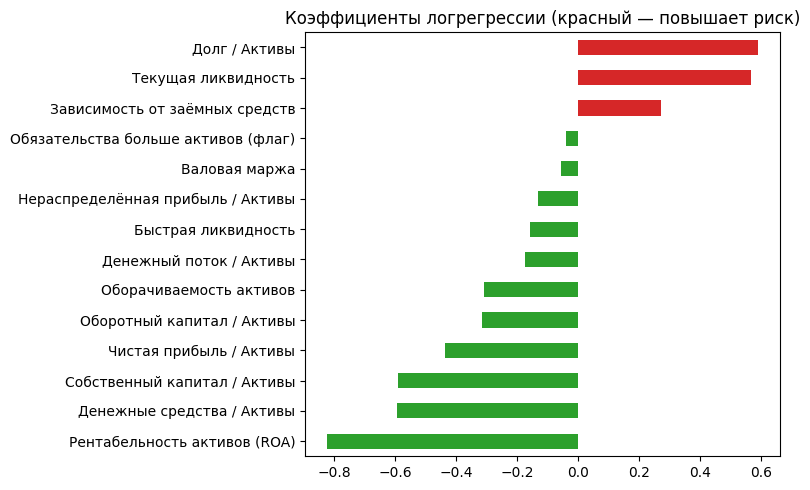

Рентабельность активов (ROA)          -0.826
Денежные средства / Активы            -0.594
Собственный капитал / Активы          -0.591
Чистая прибыль / Активы               -0.436
Оборотный капитал / Активы            -0.316
Оборачиваемость активов               -0.309
Денежный поток / Активы               -0.175
Быстрая ликвидность                   -0.159
Нераспределённая прибыль / Активы     -0.133
Валовая маржа                         -0.057
Обязательства больше активов (флаг)   -0.041
Зависимость от заёмных средств         0.272
Текущая ликвидность                    0.567
Долг / Активы                          0.591
dtype: float64

In [9]:
coef = pd.Series(logreg.named_steps["model"].coef_[0], index=X_train_w.columns).sort_values()
plt.figure(figsize=(8, 5))
coef.plot.barh(color=["tab:green" if v < 0 else "tab:red" for v in coef])
plt.title("Коэффициенты логрегрессии (красный — повышает риск)")
plt.tight_layout(); plt.show()
coef.round(3)

Отрицательный коэффициент — признак **снижает** риск банкротства, положительный — **повышает**.
Если знак противоречит экономическому смыслу, причина обычно в сильной корреляции признаков между собой
(например, ROA и «Чистая прибыль / Активы» почти дублируют друг друга) — модель «делит» эффект между ними.
Для продакшена такие дубли стоит убирать.

Здесь это видно на ликвидности: у «Текущей ликвидности» коэффициент положительный, хотя по смыслу высокая ликвидность снижает риск.
Причина — она почти дублирует «Быструю ликвидность» и «Денежные средства / Активы». Это пример того, что проверка знаков — обязательный шаг валидации.

### 3.4 Сравнение с градиентным бустингом

In [10]:
boost = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_depth=3,
                                       class_weight="balanced", random_state=SEED)
boost.fit(X_train_w, y_train)
p_gb = boost.predict_proba(X_test_w)[:, 1]

res = pd.DataFrame({
    "Gini": [gini(y_test, p) for p in (p_z, p_lr, p_gb)],
    "PR-AUC": [average_precision_score(y_test, p) for p in (p_z, p_lr, p_gb)],
}, index=["Z-индекс", "Логрегрессия", "Бустинг"]).round(3)
res

,Gini,PR-AUC
Z-индекс,0.830,0.287
Логрегрессия,0.867,0.383
Бустинг,0.854,0.390


### 3.5 Выбор порога

Модель выдаёт вероятность, а решение («отказать / одобрить / запросить документы») принимается по порогу.
Для риска банкротства пропустить будущего банкрота дороже, чем лишний раз проверить нормальную компанию,
поэтому подбираем порог так, чтобы ловить **не меньше 80% банкротов**, и смотрим, сколько ложных тревог это стоит.

In [11]:
prec, rec, thr = precision_recall_curve(y_test, p_lr)
idx = np.where(rec[:-1] >= 0.8)[0][-1]
threshold = thr[idx]
pred = (p_lr >= threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
print(f"Порог вероятности: {threshold:.3f}")
print(f"Поймали банкротов: {tp} из {tp + fn} (recall {recall_score(y_test, pred):.0%})")
print(f"Ложные тревоги: {fp} из {fp + tn} нормальных компаний ({fp / (fp + tn):.0%})")
print(f"Precision: {precision_score(y_test, pred):.1%} — доля реальных банкротов среди помеченных")

Порог вероятности: 0.618
Поймали банкротов: 53 из 66 (recall 80%)
Ложные тревоги: 172 из 1980 нормальных компаний (9%)
Precision: 23.6% — доля реальных банкротов среди помеченных


Precision низкий — это нормально при 3% банкротов: чтобы поймать большинство редких событий, приходится помечать и часть здоровых компаний.
На практике модель не отказывает автоматически, а отправляет подозрительные компании на **ручную проверку аналитиком**.

---
# 4. Связь с отчётностью (РСБУ)

В реальном применении коэффициенты считаются из строк бухгалтерской отчётности — тех же, что я извлекаю в ВКР:

| Коэффициент | Формула по строкам |
|---|---|
| Рентабельность активов | стр. 2400 (чистая прибыль) / стр. 1600 (баланс) |
| Текущая ликвидность | стр. 1200 (оборотные активы) / стр. 1500 (краткосрочные обязательства) |
| Денежные средства / Активы | стр. 1250 / стр. 1600 |
| Собственный капитал / Активы | стр. 1300 / стр. 1600 |
| Долг / Активы | (стр. 1400 + стр. 1500) / стр. 1600 |
| Оборачиваемость активов | стр. 2110 (выручка) / стр. 1600 |

То есть пайплайн «отчётность → проверка цифр (ВКР) → коэффициенты → модель риска» — это единая цепочка.

---
# 5. Выводы

1. Банкротов 3,2% — поэтому accuracy не используем, смотрим Gini, PR-AUC и recall по банкротам.
2. Нашли и обработали ошибки данных (значения-миллиарды у коэффициентов ликвидности) винзоризацией по перцентилям обучающей выборки.
3. Логистическая регрессия на 14 понятных коэффициентах заметно лучше классического Z-индекса и сопоставима с бустингом,
   при этом каждый коэффициент интерпретируем.
4. Порог подобран под бизнес-задачу: ловим 80% банкротов, ценой ложных тревог, которые уходят на ручную проверку.

**Что можно улучшить:**
- убрать дублирующие признаки (проверка корреляций и VIF);
- WoE-биннинг коэффициентов, как в скоринге физлиц, — для монотонности и устойчивости к выбросам;
- out-of-time валидация: обучать на ранних годах, проверять на поздних;
- калибровка вероятностей под реальный уровень дефолтов портфеля банка.